# Monitoring Flood Dynamics with SWOT RiverSP


_Authors: Sabrine Amzil (SERTIT), Thomas Ledauphin (SERTIT), Hervé Yésou (SERTIT), Mathilde Siméon (CNES), Damien Desroches (CNES)_
 
### Context
The Kôn River Basin is located in south-central Vietnam, mainly within Bình Định Province. The Kôn River flows from the Định Bình Reservoir towards the Thi Nai Lagoon, north of Quy Nhơn.

Between October and December 2025, heavy rainfall and typhoon events affected central Vietnam, causing widespread flooding and significant damage across the region. 

In this practical session, we will use SWOT L2 HR RiverSP Node products to monitor the Kôn River during the flood event. By comparing longitudinal water surface elevation (WSE) profiles under different hydrological conditions, we will investigate changes in river water levels and their spatial distribution. We will also examine the potential influence of river reaches, the Định Bình Reservoir, and hydraulic structures such as dams on flood conditions along the Kôn River.

We use a world image in background to render the city features.

<img src="attachment:8a4917af-92c0-4e36-a26a-a0b0ca504542.png" width="500">

Figure 1: Location of the dams on the Binh Dinh Reservoir and the Kon river. If Figure is not displayed, see slide 9.

### Requirements
1. Download the directory "RiverSP_Vietnam_flooding" (in .zip format) using the following seafile link: https://seafile.unistra.fr/d/c20a398d57c84385b0b2/ and move them in the work directory
2. Select the kernel `swot-flood` (Not needed if you work on Mybinder)
3. Run the notebook


### Content
* [I. Setup](#I.-Setup)
* [II. Flood Analysis using RiverSP](#II.-Flood-event-analysis-using-SWOT-RiverSP-observations)
* [Your turn! (Optional)](#Your-turn!-(Optional))


## I. Setup

In [ ]:
# Unzip downloaded directory in work
!unzip work/RiverSP_Vietnam_flooding.zip -d work

In [ ]:
import datetime
import glob
import io
import os
import re
from collections import defaultdict

import geopandas as gpd
import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray
import xarray as xr
from datetime import datetime, timedelta
from IPython.display import HTML
from matplotlib import colormaps
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from netCDF4 import Dataset
from PIL import Image
from shapely.geometry import Point, LineString
from shapely.geometry import Polygon, box

In [30]:
def get_world_image(bbox):
    '''This function gets world map image from arcgis server, according to bbox
    input: bbox [lonmin, latmin, lonmax, latmax] in EPSG:4326
    '''
    
    xmin, ymin, xmax, ymax = gpd.GeoDataFrame(index=[0,1,2,3], geometry=gpd.points_from_xy([bbox[0],bbox[2],bbox[0],bbox[2]], [bbox[1],bbox[1],bbox[3],bbox[3]]), crs="EPSG:4326").to_crs("EPSG:3857").total_bounds*1E-7
    
  
    ResRef = 2048 / 3
    coor = {"llon": xmin, "llat": ymin, "ulon": xmax, "ulat": ymax}

    DeltaX = float(xmax - xmin)
    DeltaY = float(ymax - ymin)
    ratio_lat_over_lon = DeltaY / DeltaX
    if DeltaX > DeltaY:
        ResX = ResRef
        ResY = int(ResRef * ratio_lat_over_lon)
    elif DeltaX < DeltaY:
        ResX = int(ResRef / ratio_lat_over_lon)
        ResY = ResRef
    else:
        ResX = ResRef
        ResY = ResRef

    # You can check for more server here: https://server.arcgisonline.com/arcgis/rest/services
    server = "https://server.arcgisonline.com/arcgis/rest/services/World_Imagery/MapServer"
    
    dpi=200
    fmt="png32"
    basemap_url = f"{server}/export?bbox={xmin}E7%2C{ymin}E7%2C{xmax}E7%2C{ymax}E7%2C&size={ResX},{ResY}&dpi={dpi}&format={fmt}&f=image"
    

    resp = requests.get(basemap_url)
 
    im = Image.open(io.BytesIO(resp.content))

    return im

In [55]:
def merge_river_product(product_cycle_link : dict, river_extent_gdf) :
    """
       Merge river products only for a defined river

    Args:
        product_cycle_link : Dict that store path of the products as values and cycle number as key
        river_extent_gdf : Extent of the river (to open the products faster)

    Returns:
            GeoDataFrame : gdf with products of the defined river
    """

    selected_results = []

    for date, file_path in product_cycle_link.items() :
        # Read shp
        print(file_path[0])
        results_gdf = gpd.read_file(file_path[0])
        # Keep only the information about the selected river
        results_gdf = gpd.overlay(results_gdf, river_extent_gdf, how="intersection")
        # Add the cycle number
        results_gdf["date"] = date
        selected_results.append(results_gdf)

    results_concat_gdf = pd.concat(selected_results)


    # Sort results
    results_concat_gdf = results_concat_gdf.sort_values(by = "time")

    return results_concat_gdf

## II. Flood event analysis using SWOT RiverSP observations

### 1. Define the search area and load the inputs

In [61]:
# Define a search area
ymin = 13.86
ymax = 14.26

xmin = 108.73
xmax = 109.23

# Folder with RiverSP Node products 
riversp_folders_paths = [r'./work/RiverSP_Vietnam_flooding/RiverSP']

# Shapefile of the river and dam location 
river_extent_path = r'./work/RiverSP_Vietnam_flooding/River_data/river_vietnam.shp'
dam_path = r'./work/RiverSP_Vietnam_flooding/River_data/Dam_location.shp'

# Output folder
output_folder = r'./work/RiverSP_Vietnam_flooding/OUTPUT'


In [34]:
# Read river location
river_extent_gdf = gpd.read_file(river_extent_path)
river_extent_gdf = river_extent_gdf.to_crs(4326)

# Read dam location
dam_gdf = gpd.read_file(dam_path)
dam_gdf = dam_gdf.to_crs(4326)

In [ ]:
# Plot the area of interest
fig, ax = plt.subplots(figsize=(12, 8))

# Background
background = plt.imshow(get_world_image([xmin, ymin, xmax, ymax]),extent=[xmin, xmax, ymin,ymax], aspect="equal")

# River extent
river_extent_gdf.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=1.5, alpha=0.8, label="River extent")
# Custom legend
river_legend = Patch(facecolor="none", edgecolor="white", linewidth=1.5, label="River extent")

# Dam locations
dam_gdf.plot(ax=ax, color="red", markersize=70, marker="^", edgecolor="black", linewidth=0.8, label="Dam")
# Plot Dam IDs
for _, row in dam_gdf.iterrows():
    x = row.geometry.x
    y = row.geometry.y
    ax.annotate(str(row["Id"]), xy=(x, y), xytext=(6, 6), textcoords="offset points", fontsize=10, fontweight="bold", color="red")
    # Custom legend
    dam_legend = Line2D([0], [0],marker="^", color="none", markerfacecolor="red", markeredgecolor="black", markersize=9, label="Dam")

# Formatting
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

ax.set_title("Area of interest", fontsize=14)

ax.grid(True, linestyle="--", alpha=0.4)

ax.legend(handles= [river_legend, dam_legend], loc="best")
plt.tight_layout()
plt.show()

# Save to png
# fig.savefig(os.path.join(output_folder, f'area_of_interest_kon_river.png'))

### 2. Load interesting portions of RiverSP products and merge different dates in one file

In [42]:
# Find all the riverSP Nodes shp path
sp_path_list = [] 
# Loop on the folders
for file in riversp_folders_paths :
    # Find all the nc
    sp_path_list += list(glob.glob(f'{file}/SWOT_L2_HR_RiverSP_Node_*.shp'))

In [ ]:
# Init the dict that will store the path by date
sp_path_dict = {date : [] for date in list(set([datetime.strptime(re.search("\\d{8}T\\d{6}", riversp_path).group()[:8], '%Y%m%d').date() for riversp_path in sp_path_list]))}

# Class the path by date in a dict
for riversp_path in sp_path_list :
    
    # Extract date of the file
    date_dt = datetime.strptime(re.search("\\d{8}T\\d{6}", riversp_path).group()[:8], '%Y%m%d').date()
    
    # Append the path to the dict
    sp_path_dict[date_dt].append(riversp_path)

sp_path_dict

In [ ]:
# Merge the riversp products
sp_df = merge_river_product(sp_path_dict, river_extent_gdf)

# Removing nodes with invalid WSE
sp_df = sp_df[sp_df["wse"] != -999999999999.0].copy()

# Keep only the attributes that you are interrested in
sp_df = sp_df.drop(sp_df.columns.difference(['reach_id','node_id','lat','lon','river_name','wse','node_q', 'geoid_hght','p_dist_out','geometry', 'date']), axis=1)

# Reset index of the geodataframe
sp_df.reset_index(drop = True, inplace = True)
sp_df

In [40]:
# Save the cleaned GeoDataFrame in gpkg format
output_file = os.path.join(output_folder,"swot_riversp_nodes_vietnam.gpkg")
sp_df.to_file(output_file, layer="riversp_nodes", driver="GPKG")

In [24]:
# Optional: Save the cleaned GeoDataFrame in csv and shp format
# sp_df.to_csv(os.path.join(output_folder, "swot_riversp_nodes_vietnam.csv"))
# output_file = os.path.join(output_folder, "swot_riversp_nodes_vietnam.shp")
# sp_df.to_file(output_file, driver="ESRI Shapefile")

### 3. Plot the spatial water elevation distribution of SWOT nodes per date and save the animation as a video

In [ ]:
# Parameters
vmin = 0
vmax = 100

# One figure per date
for date, df_date in sp_df.groupby("date"):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Background
    background = plt.imshow(get_world_image([xmin, ymin, xmax, ymax]),extent=[xmin, xmax, ymin,ymax], aspect="equal")

    # River extent
    river_extent_gdf.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=1.5, alpha=0.8, label="River extent")
    # Custom legend
    river_legend = Patch(facecolor="none", edgecolor="white", linewidth=1.5, label="River extent")
    
    # SWOT RiverSP nodes
    df_date.plot(ax=ax, column="wse", cmap="viridis", vmin=vmin, vmax=vmax, markersize=10, alpha=0.9, legend=True, legend_kwds={"label": "WSE (m)", "shrink": 0.7})
    
    # Dam locations
    dam_gdf.plot(ax=ax, color="red", markersize=70, marker="^", edgecolor="black", linewidth=0.8, label="Dam")
    # Plot Dam IDs
    for _, row in dam_gdf.iterrows():
        x = row.geometry.x
        y = row.geometry.y
        ax.annotate(str(row["Id"]), xy=(x, y), xytext=(6, 6), textcoords="offset points", fontsize=10, fontweight="bold", color="red")
        # Custom legend
        dam_legend = Line2D([0], [0],marker="^", color="none", markerfacecolor="red", markeredgecolor="black", markersize=9, label="Dam")
    
    # Formatting
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")

    ax.set_title(f"SWOT RiverSP Nodes\nDate: {str(date)[:10]}", fontsize=14)

    ax.grid(True, linestyle="--", alpha=0.4)

    ax.legend(handles= [river_legend, dam_legend], loc="best")
    plt.tight_layout()
    plt.show()
    
    # Save to png
    fig.savefig(os.path.join(output_folder, f'swot_riversp_nodes_{date}.png'))

### 4. Plot the longitudinal profile of the WSE

In [ ]:
# Sort the data by date and distance to outlet
sp_df = sp_df.sort_values(["date", "p_dist_out"])

fig, ax = plt.subplots(figsize=(12, 6))

for date, df in sp_df.groupby("date"):
    ax.plot(
        df["p_dist_out"],  # distance to the outlet (m)
        df["wse"],
        "o",
        markersize=2,
        linewidth=2,
        label=str(date)[:10]
)
# Reverse the x-axis so that the profile is displayed from upstream (left) to downstream/outlet (right)
ax.invert_xaxis()
# Set y-axis ticks every 10 meters
ax.yaxis.set_major_locator(MultipleLocator(10))

ax.set_xlabel("Distance to outlet (m)")
ax.set_ylabel("WSE (m)")
ax.set_title("Longitudinal profile using SWOT RiverSP Nodes products")

ax.grid(True, alpha=0.3)
ax.legend(title="Date")

plt.tight_layout()
plt.show()

# Save to png
fig.savefig(os.path.join(output_folder, f'longitudinal_profile_swot_riversp_nodes.png'))

#### Questions

1. Based on the longitudinal WSE profiles, identify the profiles corresponding to normal, decreasing water-level, and flood conditions. You can use Copernicus Browser to verify the water surface conditions of the lake/river on the three analyzed dates, or on dates close to them, using Sentinel-1 or Sentinel-2 imagery. Link: https://browser.dataspace.copernicus.eu/

   01/08/2024:

   12/08/2025:

   24/11/2025:

3. The first dam is located at the outlet of the lake. Based on the WSE profiles and the maps, discuss the possible role of this dam during the flood event. How could its operation contribute to flood mitigation downstream?

Technical parameters for the Định Bình Reservoir are available here: https://www.hec.com.vn/content/reservoir/dinh-binh-reservoir.html



#### Analysis

If multiple SWOT RiverSP Nodes are processed, you can obtain the following type of graph, providing a more complete longitudinal profile of the river and showing the range of water surface elevations observed under different hydrological conditions.

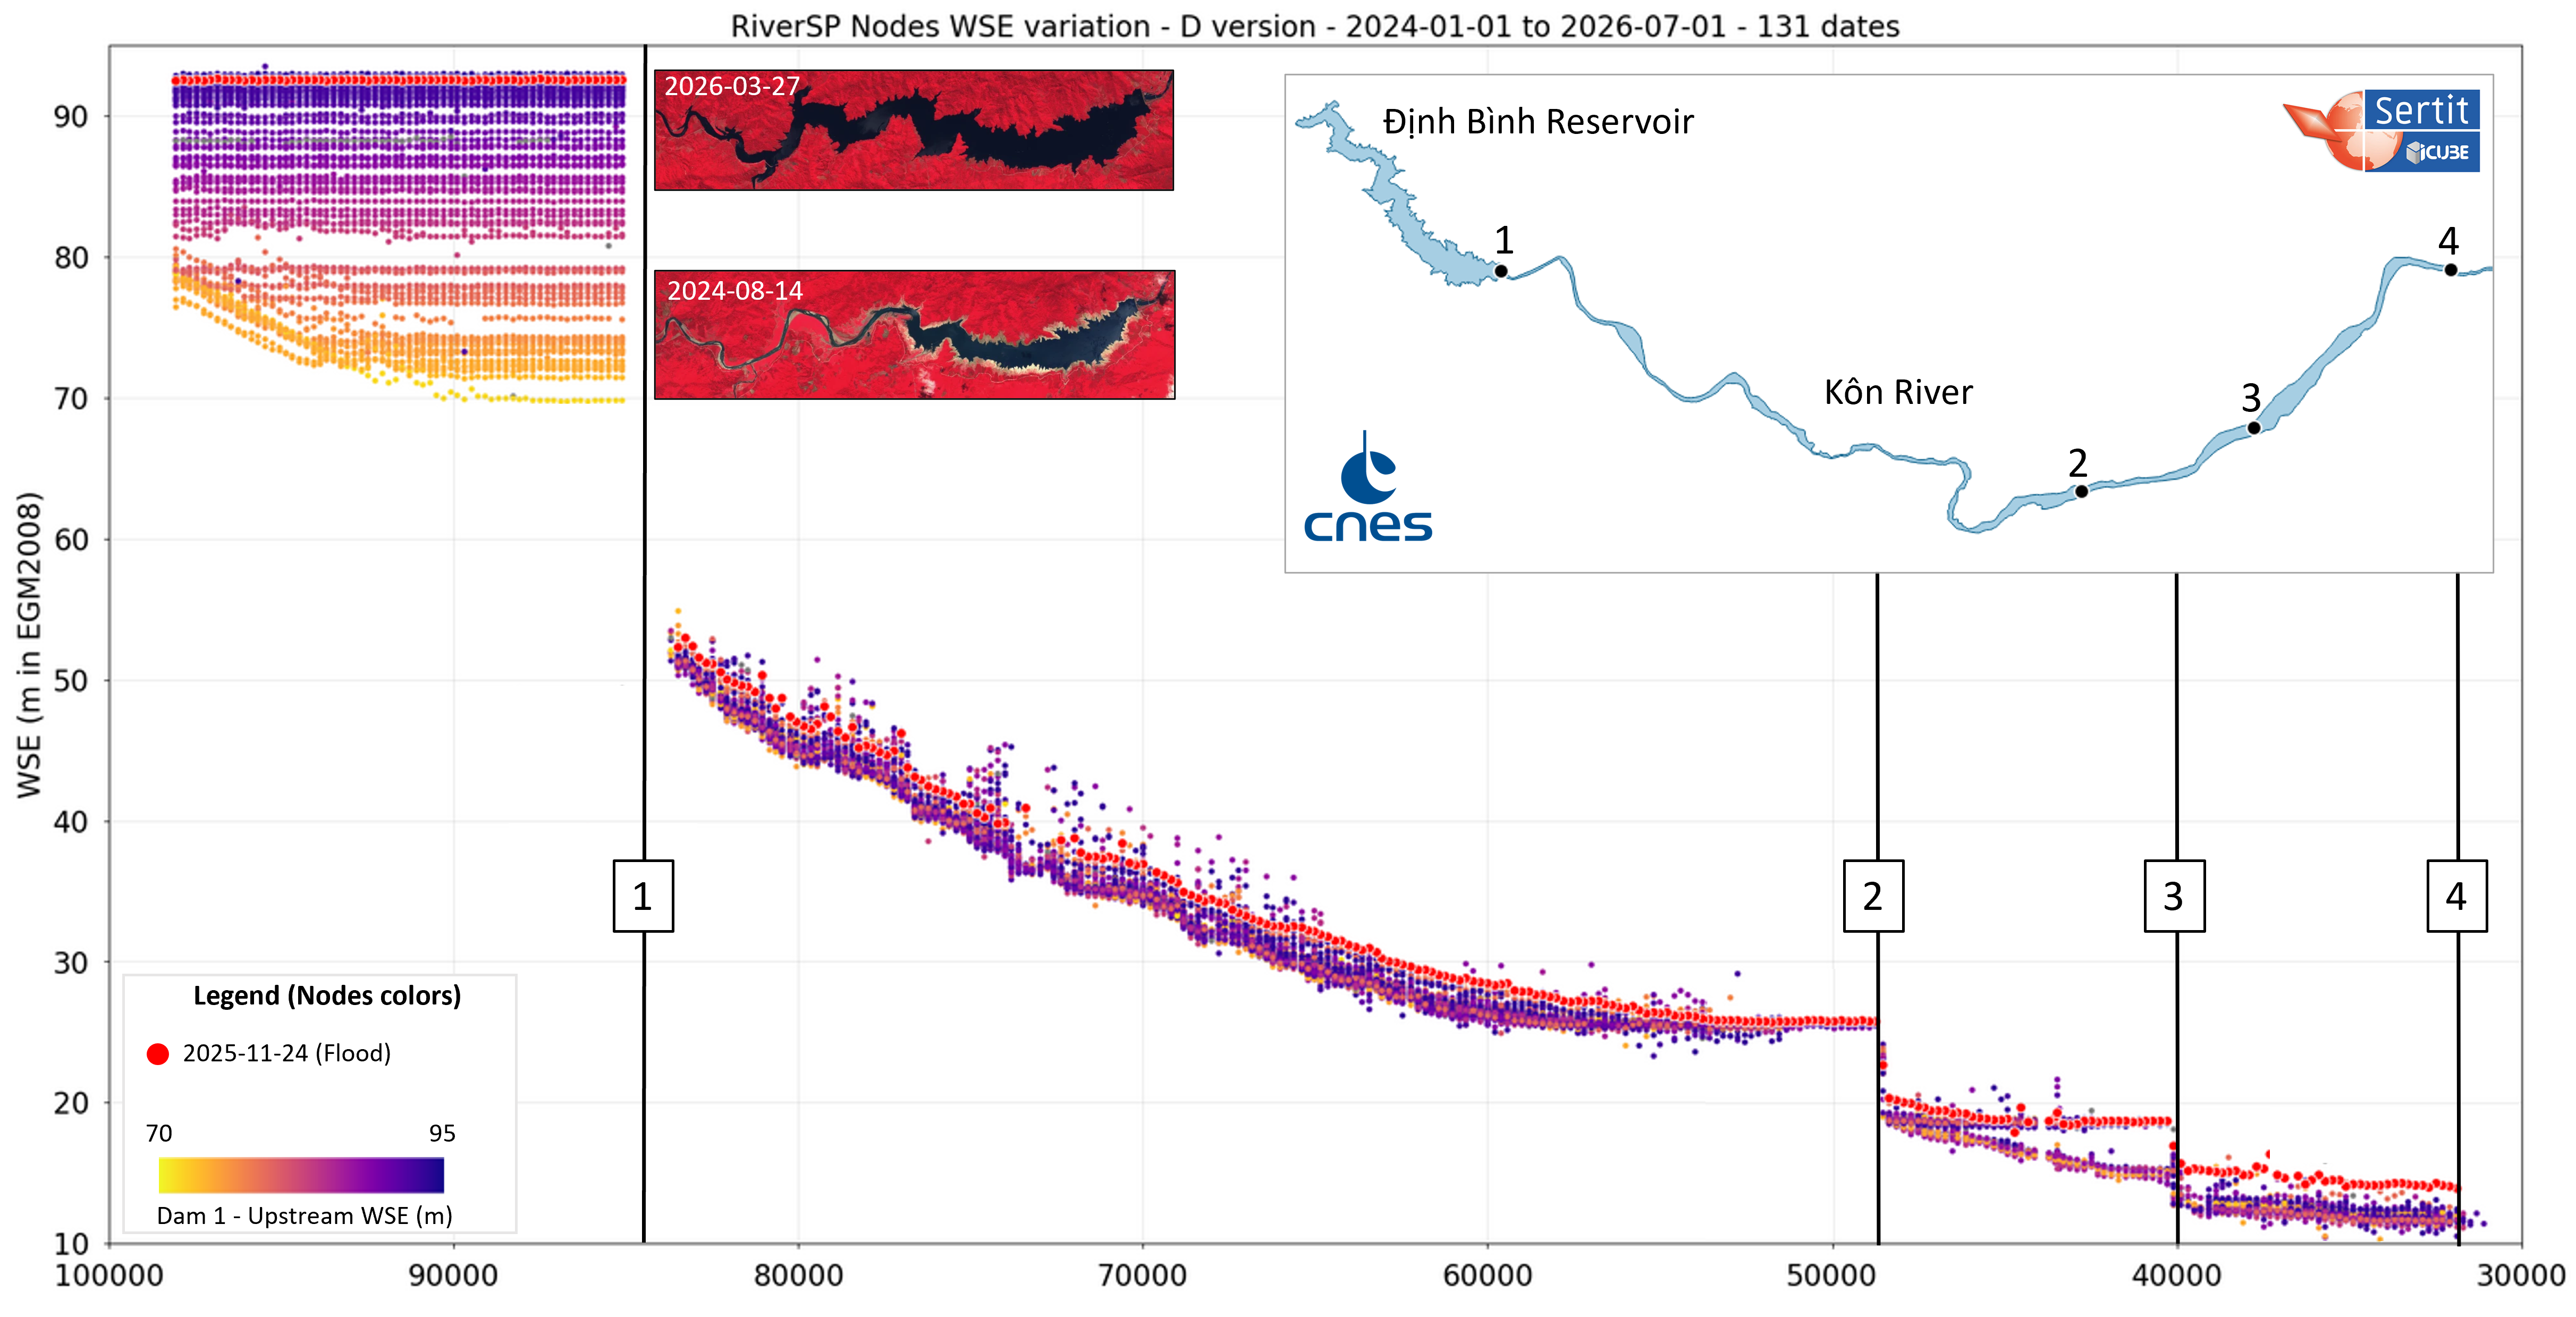

Figure 2: Longitudinal profile of the Kon River using SWOT RiverSP Nodes water surface height variations between 2024 and 2026. If Figure is not displayed, see slide 10.

#### Conclusion
The longitudinal WSE profiles derived from SWOT RiverSP Nodes observations provide a spatially continuous representation of the river's water-surface elevation in different hyrological cycles.

We can identify different hydraulic reaches and characterize the influence of catchment and sub-catchment processes along the river:
Significant changes in the hydraulic regime can be identified along the river. In particular, abrupt changes or localized decreases in WSE may indicate hydraulic controls, such as dams and reservoirs, as well as transitions between river reaches or the influence of tributary inflows.


## Your turn! (Optional)
Download an additional SWOT RiverSP Node observation and update the longitudinal WSE profile of your choice.

How does the new observation compare with the existing profiles?
